<a href="https://colab.research.google.com/github/sebastianvettel1212/scikit-learn-cookbook/blob/main/scikit_learn_Cookbook_Chapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 3 — Teknik Reduksi Dimensi (*Dimensionality Reduction Techniques*)

**Buku:** *scikit-learn Cookbook, Third Edition* — John Sukup (Packt Publishing)

Notebook ini berisi:
1. **Reproduksi kode** seluruh *recipe* Bab 3 (dari repositori resmi buku, termasuk solusi latihan),
2. **Ringkasan** tiap subbab, dan
3. **Penjelasan teori** dalam Bahasa Indonesia.

---

## Daftar Isi
0. Pengantar Reduksi Dimensi
1. PCA (*Principal Component Analysis*)
2. LDA (*Linear Discriminant Analysis*)
3. Perbedaan PCA dan LDA
4. t-SNE untuk Visualisasi Data
5. Panduan Memilih Teknik Reduksi Dimensi
6. Latihan Praktik
7. Ringkasan Bab

---

## 0. Pengantar Reduksi Dimensi

**Reduksi dimensi** adalah proses mengurangi jumlah fitur (dimensi) dalam data sambil mempertahankan informasi terpenting.

### Mengapa penting?
- **Curse of dimensionality:** makin banyak dimensi, data makin "renggang" sehingga jarak antar titik kurang bermakna dan model butuh data jauh lebih banyak.
- **Overfitting:** banyak fitur membuat model mudah menghafal noise.
- **Efisiensi komputasi:** fitur lebih sedikit → pelatihan lebih cepat dan hemat memori.
- **Visualisasi:** manusia hanya bisa melihat 2D/3D, sehingga data berdimensi tinggi perlu diproyeksikan.
- **Mengurangi multikolinearitas/redundansi** antarfitur.

### Dua pendekatan
| Pendekatan | Ide | Contoh |
|---|---|---|
| **Feature selection** | Memilih subset fitur asli | `RFE`, `SelectFromModel` (Bab 2) |
| **Feature extraction** | Membuat fitur baru dari kombinasi fitur asli | PCA, LDA, t-SNE |

### Landasan teori
Pada reduksi linear, data dalam ruang berdimensi $d$ diproyeksikan ke ruang berdimensi $k<d$ lewat matriks proyeksi $W$:
$$Z = XW$$
PCA memilih $W$ untuk memaksimalkan variansi; LDA memilih $W$ untuk memaksimalkan separasi kelas; t-SNE mempertahankan struktur tetangga lokal secara non-linear.

## Persiapan

In [1]:
!pip install numpy pandas scikit-learn matplotlib

---
## 1. PCA (*Principal Component Analysis*)

PCA adalah teknik reduksi dimensi **tak terawasi (*unsupervised*)** yang mentransformasi data ke sistem koordinat baru; sumbu-sumbunya (*principal components*) **diurutkan berdasarkan besarnya variansi yang dijelaskan**.

### Konsep kunci
- PCA mencari **arah dengan variansi maksimum** pada data.
- Komponen saling **ortogonal** (tegak lurus, tidak berkorelasi).
- Komponen pertama menjelaskan variansi terbesar, lalu komponen kedua, dan seterusnya.
- Memerlukan **data yang distandardisasi**.

### Getting ready
Dataset **Wine** (178 sampel, 13 fitur kimia, 3 kelas anggur) dari scikit-learn.

In [2]:
# Load libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
import warnings

# Set random seed for reproducibility and suppress warnings
np.random.seed(2024)
warnings.simplefilter(action='ignore', category=FutureWarning)

#Load dataset
wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
target_wine = wine.target
display(df_wine.head(10))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


### How to do it...
Kita merangkai `StandardScaler` dan `PCA(n_components=2)` dalam `Pipeline()` (konvensi yang dipakai di seluruh buku), lalu memvisualisasikan data pada dua komponen utama beserta arah vektor komponennya.

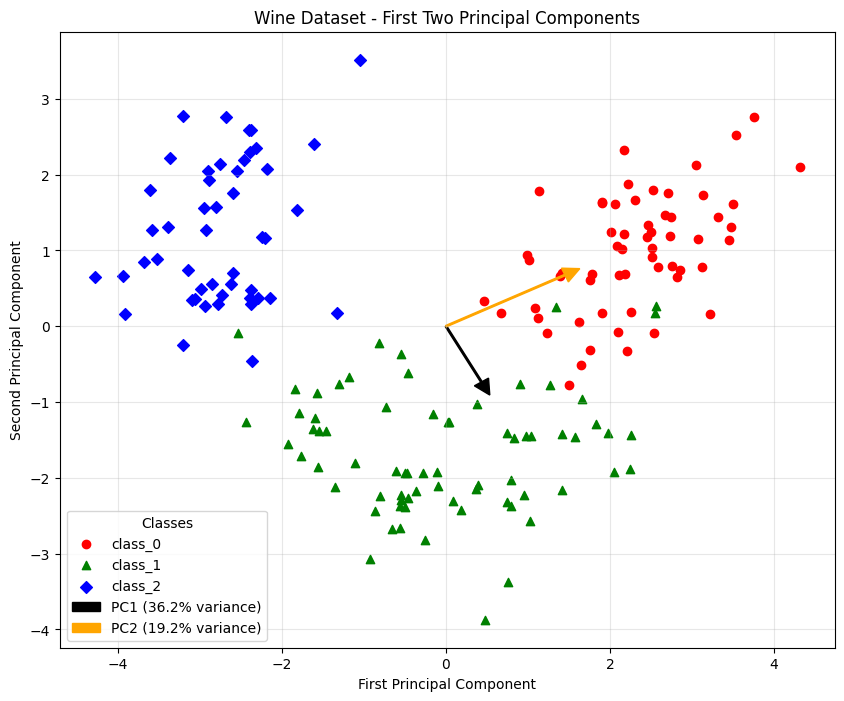

In [3]:
# Load libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Create a pipeline for PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Always scale before PCA
    ('pca', PCA(n_components=2))   # Reduce to 2 dimensions
])

# Fit and transform the data
X_pca = pca_pipeline.fit_transform(df_wine)

# Visualize the transformed data
plt.figure(figsize=(10, 8))
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot the scatter points
for i, (shape, color) in enumerate(zip(shapes, colors)):
    plt.scatter(X_pca[target_wine == i, 0], X_pca[target_wine == i, 1],
                c=color, marker=shape, label=wine.target_names[i])

# Get the PCA components and plot as vectors
pca = pca_pipeline.named_steps['pca']
origin = np.zeros(2)  # Origin point for vectors
arrow_colors = ['black', 'orange']

# Scale the components by their explained variance ratio for better visualization
scaling = 3
for i, (component, ratio) in enumerate(zip(pca.components_, pca.explained_variance_ratio_)):
    plt.arrow(origin[0], origin[1],
              component[0] * scaling, component[1] * scaling,
              color=arrow_colors[i],
              width=0.02, head_width=0.2, head_length=0.2,
              label=f'PC{i+1} ({ratio:.1%} variance)')

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - First Two Principal Components')
plt.legend(title="Classes")
plt.grid(True, alpha=0.3)
plt.show()

**Interpretasi:** 13 fitur diringkas menjadi 2 komponen, dan tiga kelas anggur sudah terlihat cukup terpisah walau PCA **tidak menggunakan label kelas**. Artinya arah variansi terbesar kebetulan juga membawa informasi kelas.

### How it works...
PCA mengidentifikasi arah (*principal components*) tempat data paling bervariasi. Komponen-komponen itu adalah **kombinasi linear fitur asli** dan saling ortogonal. Secara matematis, komponen adalah **vektor eigen** dari matriks kovarians data, dan variansi yang dijelaskan adalah **nilai eigen**-nya:
$$\Sigma v_i=\lambda_i v_i,\qquad \text{explained variance ratio}_i=\frac{\lambda_i}{\sum_j\lambda_j}$$
Grafik berikut menunjukkan rasio variansi yang dijelaskan tiap komponen.

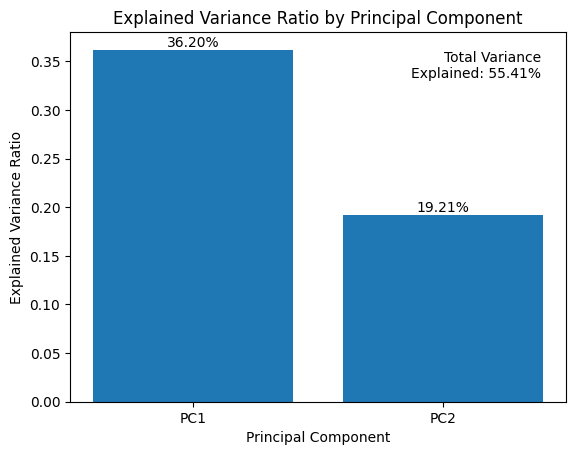

In [4]:
# Get the explained variance ratio
pca = pca_pipeline.named_steps['pca']
explained_variance_ratio = pca.explained_variance_ratio_

# Calculate cumulative variance
cumulative_variance = np.sum(explained_variance_ratio)

# Plot barchart
fig, ax = plt.subplots()

x = np.arange(1, len(explained_variance_ratio) + 1)
y = explained_variance_ratio
bars = ax.bar(x, y)

# Add percentage labels on bars
for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2%}',
                        ha='center', va='bottom')

# Add cumulative variance text in upper right
ax.text(0.95, 0.95, f'Total Variance\nExplained: {cumulative_variance:.2%}',
                transform=ax.transAxes,
                ha='right', va='top',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Set custom x-axis labels for the two principal components
ax.set_xticks(x)
ax.set_xticklabels(['PC1', 'PC2'])

ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance Ratio by Principal Component')
plt.show()

**Interpretasi:** dua komponen pertama bersama-sama menjelaskan sekitar **55%** variansi total (PC1 ≈ 36,2% dan PC2 ≈ 19,2%). Sisa informasi tersebar pada 11 komponen lain.

### Perbandingan sebelum dan sesudah PCA
1. **Baris atas:** dua pasang fitur asli yang sudah distandardisasi ("Alcohol vs Malic Acid" dan "Flavanoids vs Proanthocyanins"), diberi warna dan penanda per kelas. Terlihat tumpang-tindih dan pemisahan antarkelas pada ruang fitur mentah.
2. **Baris bawah:** data yang sama setelah PCA, yaitu diputar ke arah PC1 dan PC2 (panah menunjukkan arah komponen). PCA mengorientasikan ulang data sepanjang arah variansi terbesar.

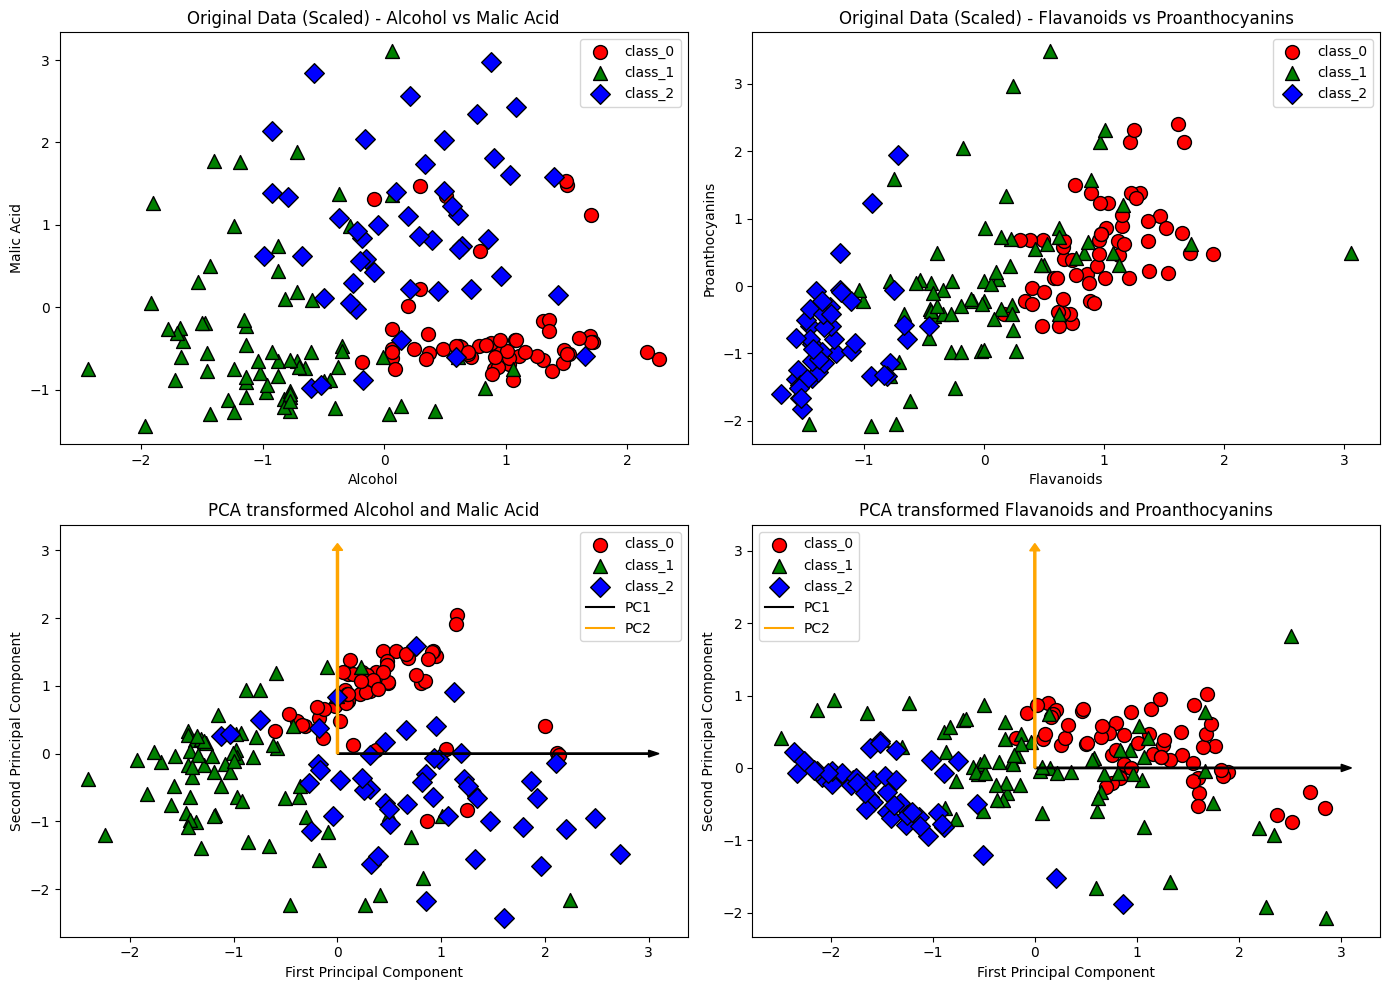

In [5]:
# Choose two features: 'alcohol' and 'malic_acid'
features_1 = ['alcohol', 'malic_acid']
df_wine_subset_1 = df_wine[features_1]
df_wine_subset_1 = pd.DataFrame(StandardScaler().fit_transform(df_wine_subset_1), columns=features_1)

# Perform PCA on the two features
pca_2d_1 = PCA(n_components=2)
X_pca_2d_1 = pca_2d_1.fit_transform(df_wine_subset_1)

# Choose two different features: 'flavanoids' and 'proanthocyanins'
features_2 = ['flavanoids', 'proanthocyanins']
df_wine_subset_2 = df_wine[features_2]
df_wine_subset_2 = pd.DataFrame(StandardScaler().fit_transform(df_wine_subset_2), columns=features_2)

# Perform PCA on the two different features
pca_2d_2 = PCA(n_components=2)
X_pca_2d_2 = pca_2d_2.fit_transform(df_wine_subset_2)

# Create a figure with four subplots in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data plot 1 (top left)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0,0].scatter(df_wine_subset_1['alcohol'][mask],
                     df_wine_subset_1['malic_acid'][mask],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[0,0].set_xlabel('Alcohol')
axes[0,0].set_ylabel('Malic Acid')
axes[0,0].set_title('Original Data (Scaled) - Alcohol vs Malic Acid')
axes[0,0].legend()

# Original data plot 2 (top right)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0,1].scatter(df_wine_subset_2['flavanoids'][mask],
                     df_wine_subset_2['proanthocyanins'][mask],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[0,1].set_xlabel('Flavanoids')
axes[0,1].set_ylabel('Proanthocyanins')
axes[0,1].set_title('Original Data (Scaled) - Flavanoids vs Proanthocyanins')
axes[0,1].legend()

# PCA plot 1 (bottom left)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[1,0].scatter(X_pca_2d_1[mask, 0],
                     X_pca_2d_1[mask, 1],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[1,0].set_xlabel('First Principal Component')
axes[1,0].set_ylabel('Second Principal Component')
axes[1,0].set_title('PCA transformed Alcohol and Malic Acid')

# Plot the principal components as vectors for the first PCA plot
origin_1 = np.zeros(2)
components_1 = np.eye(2)
arrow_colors_1 = ['black', 'orange']
scaling = 3
for i, component in enumerate(components_1):
    axes[1,0].arrow(origin_1[0], origin_1[1], component[0] * scaling, component[1] * scaling,
                    color=arrow_colors_1[i], width=0.02, head_width=0.1, head_length=0.1)
    axes[1,0].plot([], [], color=arrow_colors_1[i], label=f'PC{i+1}')

axes[1,0].legend()

# PCA plot 2 (bottom right)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[1,1].scatter(X_pca_2d_2[mask, 0],
                     X_pca_2d_2[mask, 1],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[1,1].set_xlabel('First Principal Component')
axes[1,1].set_ylabel('Second Principal Component')
axes[1,1].set_title('PCA transformed Flavanoids and Proanthocyanins')

# Plot the principal components as vectors for the second PCA plot
origin_2 = np.zeros(2)
components_2 = np.eye(2)
for i, component in enumerate(components_2):
    axes[1,1].arrow(origin_2[0], origin_2[1], component[0] * scaling, component[1] * scaling,
                    color=arrow_colors_1[i], width=0.02, head_width=0.1, head_length=0.1)
    axes[1,1].plot([], [], color=arrow_colors_1[i], label=f'PC{i+1}')

axes[1,1].legend()

plt.tight_layout()
plt.show()

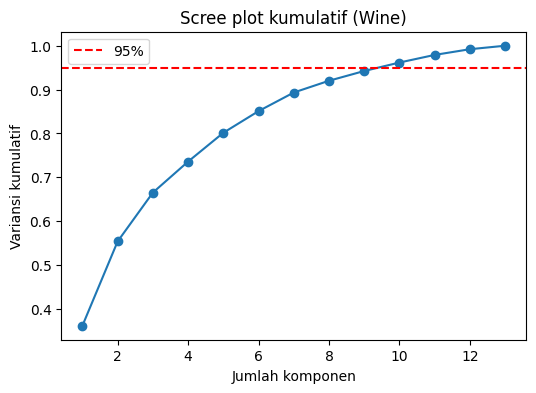

Komponen untuk >= 95% variansi: 10


In [6]:
# Tambahan (tidak ada di kode buku): berapa komponen yang dibutuhkan agar variansi kumulatif >= 95%?
pca_full = Pipeline([('scaler', StandardScaler()), ('pca', PCA())]).fit(df_wine)
cum = np.cumsum(pca_full.named_steps['pca'].explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum) + 1), cum, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95%')
plt.xlabel('Jumlah komponen')
plt.ylabel('Variansi kumulatif')
plt.title('Scree plot kumulatif (Wine)')
plt.legend()
plt.show()
print('Komponen untuk >= 95% variansi:', int(np.argmax(cum >= 0.95) + 1))

**Interpretasi:** kurva kumulatif membantu menentukan **jumlah komponen** yang dipertahankan; di sini dibutuhkan sekitar 10 dari 13 komponen untuk mencapai 95% variansi. Pada data Wine reduksi ke 2D memang kehilangan cukup banyak informasi, tetapi cukup untuk visualisasi.

### Best Practices untuk PCA
1. **Selalu lakukan scaling** sebelum PCA.
2. Periksa *explained variance ratio* untuk menentukan jumlah komponen.
3. Gunakan PCA untuk: reduksi dimensi, ekstraksi fitur, dan visualisasi data.

### Common Pitfalls
- Tidak melakukan scaling sebelum PCA.
- Memakai PCA saat **interpretabilitas fitur asli** penting (komponen adalah campuran fitur).
- Mempertahankan terlalu sedikit atau terlalu banyak komponen.

### Key Ideas
- PCA: *unsupervised*, maksimalkan variansi, komponen ortogonal.
- Pilih jumlah komponen dari variansi kumulatif (mis. 90–95%).

---
## 2. LDA (*Linear Discriminant Analysis*)

LDA adalah teknik reduksi dimensi **terawasi (*supervised*)** yang mencari kombinasi linear fitur yang **paling baik memisahkan kelas**.

### Konsep kunci
- **Memaksimalkan separasi kelas**: jarak antar-rata-rata kelas besar, sebaran dalam kelas kecil.
- Dapat dipakai untuk **reduksi dimensi** maupun **klasifikasi**.
- Memakai **label kelas** (*supervised*).
- Jumlah komponen maksimum = $\min(\text{jumlah fitur},\ \text{jumlah kelas}-1)$. Untuk Wine: $\min(13, 3-1)=2$.

### Teori
LDA memaksimalkan rasio *between-class scatter* terhadap *within-class scatter*:
$$J(w)=\frac{w^\top S_B\,w}{w^\top S_W\,w}$$
dengan $S_B$ matriks sebaran antar-kelas dan $S_W$ matriks sebaran dalam-kelas.

### Getting ready
Memakai dataset Wine yang sama.

### How to do it...
Sama seperti PCA, cukup satu kelas, dan kita juga merangkai scaling dengan `Pipeline()`. Perbedaan penting: `fit_transform` menerima **`y`** (label).

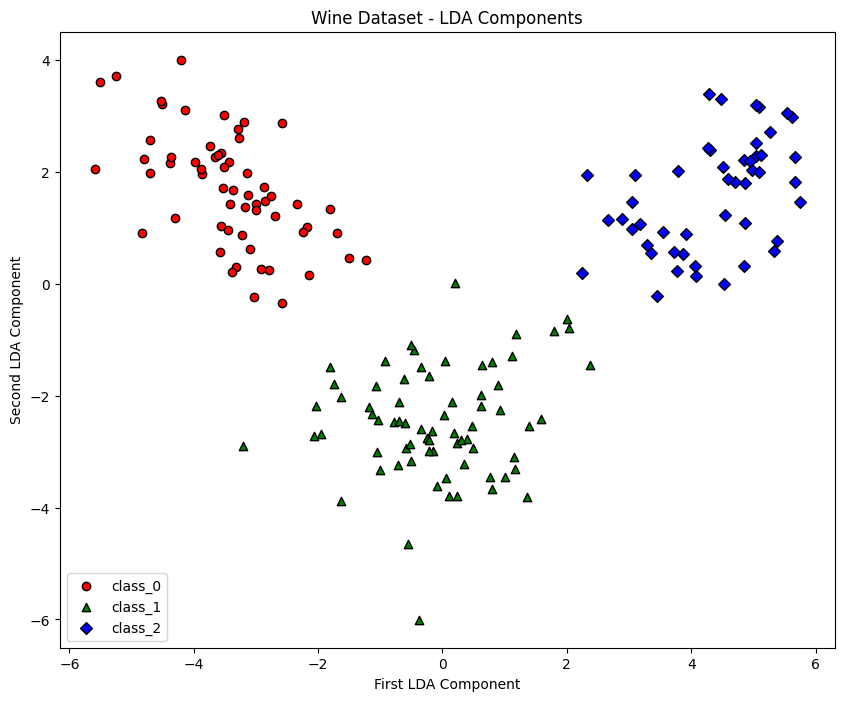

In [7]:
# Load libraries
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Split wine dataset by features and target
X_wine, y_wine = wine.data, wine.target

# Create LDA pipeline for wine dataset
lda_pipeline_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2))  # min(n_features, n_classes - 1) for wine dataset is 2
])

# Fit and transform the wine data
X_lda_wine = lda_pipeline_wine.fit_transform(X_wine, y_wine)

# Visualize LDA transformation for wine dataset
plt.figure(figsize=(10, 8))

# Define markers and colors for each class
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot each class with different marker and color
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()
plt.show()

**Interpretasi:** ketiga kelas anggur terpisah **sangat jelas** pada 2 komponen LDA, lebih baik daripada PCA, karena LDA memang dioptimalkan untuk pemisahan kelas.

### How it works...
LDA mencari kombinasi linear fitur yang paling baik memisahkan dua atau lebih kelas. Walau PCA dan LDA sama-sama untuk reduksi dimensi, tujuan dan metodenya berbeda. Secara visual keduanya bisa terlihat mirip, bergantung pada dataset. Berikut perbandingan berdampingan.

## 3. Perbedaan PCA dan LDA

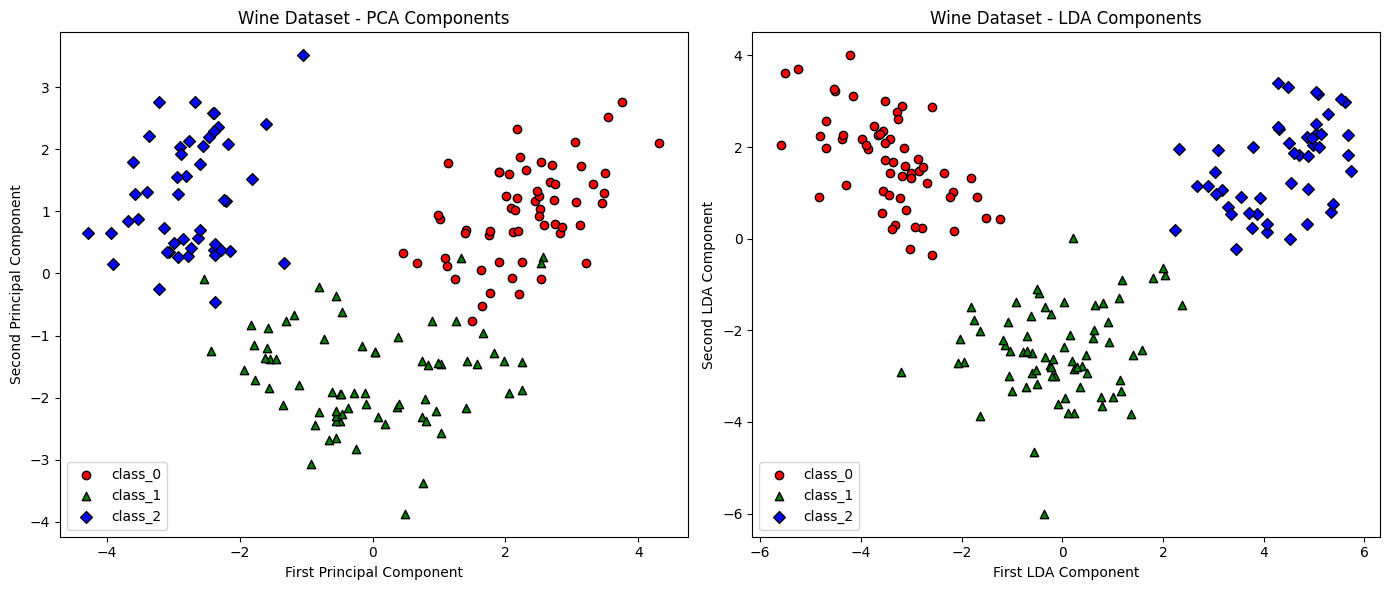

In [8]:
# Create side-by-side plots
plt.figure(figsize=(14, 6))

plt.subplot(121)
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - PCA Components')
plt.legend()

plt.subplot(122)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()

plt.tight_layout()
plt.show()

| Aspek | **PCA** | **LDA** |
|---|---|---|
| Jenis | *Unsupervised* | *Supervised* |
| Tujuan | Memaksimalkan **variansi** | Memaksimalkan **separasi kelas** |
| Memakai label `y` | Tidak | Ya |
| Jumlah komponen maks | $\min(n_{sampel}, n_{fitur})$ | $\min(n_{fitur}, n_{kelas}-1)$ |
| Asumsi | Hubungan linear | Distribusi normal tiap kelas dan kovarians kelas yang serupa |
| Cocok untuk | Kompresi, denoising, eksplorasi | Praproses klasifikasi, memisahkan kelas |

### Best Practices untuk LDA
1. Scaling fitur sebelum LDA.
2. Gunakan saat **pemisahan kelas** penting.
3. Periksa asumsi (distribusi normal, homoskedastisitas).

### Common Pitfalls
- Memakai LDA dengan kelas yang **sangat tidak seimbang**.
- Menerapkannya pada data yang tidak berdistribusi normal.
- Memakainya saat kelas memiliki struktur kovarians yang sangat berbeda.

### Key Ideas
- LDA memanfaatkan label untuk menemukan sumbu yang memisahkan kelas.
- Maksimum komponen = jumlah kelas − 1.

---
## 4. t-SNE untuk Visualisasi Data

**t-SNE** (*t-distributed Stochastic Neighbor Embedding*) adalah teknik reduksi dimensi **non-linear** yang sangat cocok untuk **visualisasi** data berdimensi tinggi.

### Konsep kunci
- Mempertahankan **struktur lokal** (titik yang berdekatan tetap berdekatan).
- Transformasi **non-linear**.
- Terutama untuk **visualisasi** (2D/3D).

### Teori ringkas
t-SNE mengubah jarak antar titik di ruang asal menjadi **probabilitas kemiripan** (distribusi Gaussian), lalu mencari penempatan titik di 2D/3D yang kemiripannya (distribusi **t Student**, berekor tebal) sedekat mungkin dengan aslinya dengan meminimalkan **KL divergence**. Ekor tebal distribusi t mencegah titik menumpuk di tengah (*crowding problem*). Parameter penting: **`perplexity`** (kira-kira banyaknya tetangga efektif; umumnya 5 sampai 50).

### Getting ready
Dataset **Digits** (versi kecil MNIST: 1.797 gambar digit tulisan tangan 8×8 piksel = 64 fitur, 10 kelas).

In [9]:
# Load libraries
from sklearn.datasets import load_digits

# Load dataset
digits = load_digits()

### How to do it...
Kembali dengan `Pipeline()`: scaling lalu t-SNE ke 2 dimensi.

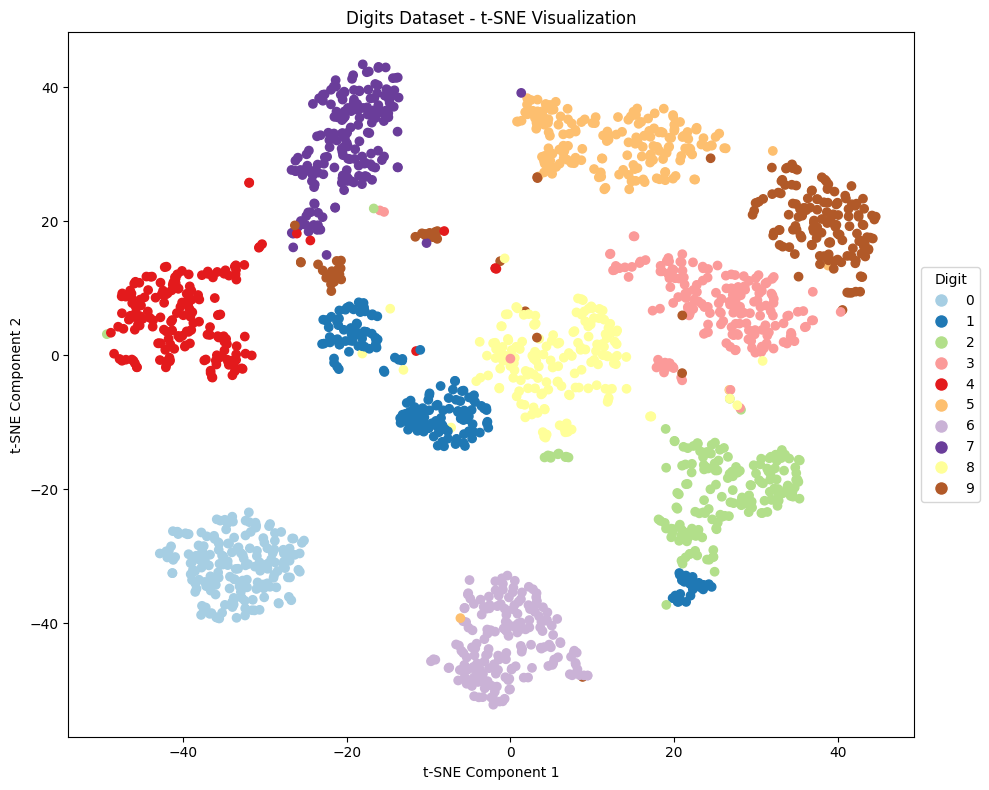

In [10]:
# Load libraries
from sklearn.manifold import TSNE

# Create t-SNE pipeline
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=2024))
])

# Fit and transform the digits data
X_tsne = tsne_pipeline.fit_transform(digits.data)
# Visualize t-SNE results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=digits.target, cmap='Paired', label=digits.target)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Digits Dataset - t-SNE Visualization')

# Create legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                             markerfacecolor=plt.cm.Paired(i/9),
                             label=str(i), markersize=10)
                  for i in range(10)]
plt.legend(handles=legend_elements, title='Digit', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

**Interpretasi:** dari 64 dimensi menjadi 2 dimensi, kesepuluh digit membentuk **klaster yang terpisah jelas**. Ini menunjukkan t-SNE mempertahankan struktur lokal data dengan baik.

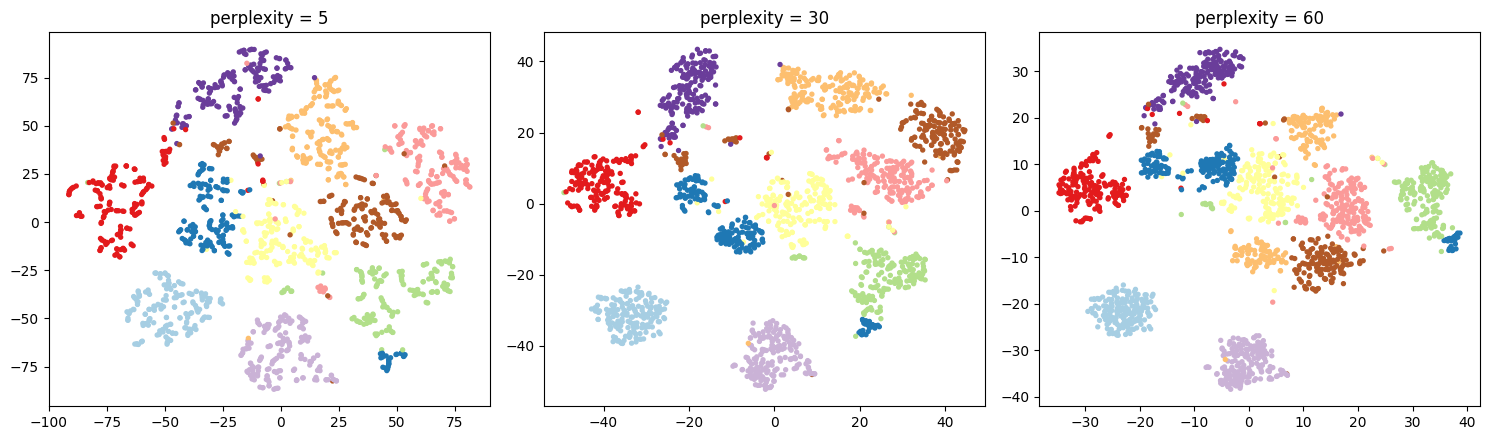

In [11]:
# Tambahan (tidak ada di kode buku): pengaruh perplexity pada hasil t-SNE
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
X_scaled_digits = StandardScaler().fit_transform(digits.data)
for ax, perp in zip(axes, [5, 30, 60]):
    emb = TSNE(n_components=2, perplexity=perp, random_state=2024).fit_transform(X_scaled_digits)
    ax.scatter(emb[:, 0], emb[:, 1], c=digits.target, cmap='Paired', s=8)
    ax.set_title(f'perplexity = {perp}')
plt.tight_layout()
plt.show()

**Interpretasi:** `perplexity` kecil menekankan struktur sangat lokal (klaster kecil terpecah), perplexity besar menekankan struktur yang lebih global. Karena itu parameter ini perlu dieksperimenkan.

### Best Practices untuk t-SNE
1. Scaling data sebelum t-SNE.
2. Eksperimen dengan parameter **perplexity**.
3. Gunakan terutama untuk **visualisasi**.

### Common Pitfalls
- Memakai t-SNE sebagai langkah reduksi dimensi **di dalam pipeline model** (t-SNE tidak punya `transform()` untuk data baru, hanya `fit_transform()`).
- Terlalu menafsirkan **struktur global**: jarak antar klaster dan ukuran klaster pada plot t-SNE **tidak bermakna** secara kuantitatif.
- Tidak menyetel perplexity.

### Key Ideas
- t-SNE: non-linear, mempertahankan struktur lokal, untuk visualisasi.
- Tidak cocok untuk transformasi data baru atau preprocessing model.

---
## 5. Panduan Memilih Teknik Reduksi Dimensi

| Kriteria | PCA | LDA | t-SNE |
|---|---|---|---|
| Ada label? | Tidak perlu | **Perlu** | Tidak perlu |
| Linear / non-linear | Linear | Linear | **Non-linear** |
| Tujuan utama | Kompresi, variansi | Separasi kelas | **Visualisasi** |
| Bisa `transform()` data baru? | Ya | Ya | **Tidak** |
| Kecepatan | Cepat | Cepat | Lambat pada data besar |
| Interpretabilitas | Sedang (loading) | Sedang | Rendah |

### Langkah praktis memilih
1. Tentukan **tujuan**: visualisasi, mempercepat model, atau meningkatkan akurasi.
2. Cek apakah ada **label** dan **hubungan linear**.
3. Standardisasi data, coba PCA sebagai baseline.
4. Bandingkan dampak terhadap **performa model** dengan *cross-validation*.

### Dampak pada performa model dan *trade-off*
Reduksi dimensi dapat mempercepat pelatihan dan mengurangi overfitting, tetapi **sebagian informasi hilang** dan interpretabilitas fitur asli berkurang. Jadi perlu diuji secara empiris, bukan diasumsikan selalu membantu.

---
## 6. Latihan Praktik: Reduksi Dimensi

### Latihan 1: PCA dengan Regresi Logistik
Bandingkan performa klasifikasi **dengan dan tanpa PCA** pada dataset Digits. PCA mempertahankan 95% variansi (`n_components=0.95`).

In [12]:
# Load libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=2024
)

# Pipeline without PCA
pipeline_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

# Pipeline with PCA
pipeline_with_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # Keep 95% of variance
    ('clf', LogisticRegression(max_iter=1000))
])

# Fit and evaluate both pipelines
pipeline_no_pca.fit(X_train, y_train)
pipeline_with_pca.fit(X_train, y_train)

# Print results
print("Accuracy without PCA:",
      accuracy_score(y_test, pipeline_no_pca.predict(X_test)))
print("Accuracy with PCA:",
      accuracy_score(y_test, pipeline_with_pca.predict(X_test)))

Accuracy without PCA: 0.975
Accuracy with PCA: 0.9638888888888889


In [13]:
# Tambahan (tidak ada di kode buku): berapa dimensi yang tersisa setelah PCA 95%?
print('Dimensi asli    :', X_train.shape[1])
print('Dimensi setelah PCA:', pipeline_with_pca.named_steps['pca'].n_components_)

Dimensi asli    : 64
Dimensi setelah PCA: 39


**Interpretasi:** PCA mengurangi jumlah fitur dari 64 menjadi 39 (sekitar 39% lebih sedikit), sementara akurasi hanya turun tipis dari ≈97,5% menjadi ≈96,4%. Ini contoh bahwa PCA dapat **mengompresi data dengan sedikit pengorbanan performa**; apakah penurunan tipis itu sepadan bergantung pada kebutuhan (kecepatan, memori, risiko overfitting).

### Latihan 2: t-SNE untuk Visualisasi Klaster
Bandingkan **label asli** dengan **klaster hasil K-means** pada ruang t-SNE untuk melihat seberapa baik struktur klaster dipertahankan.

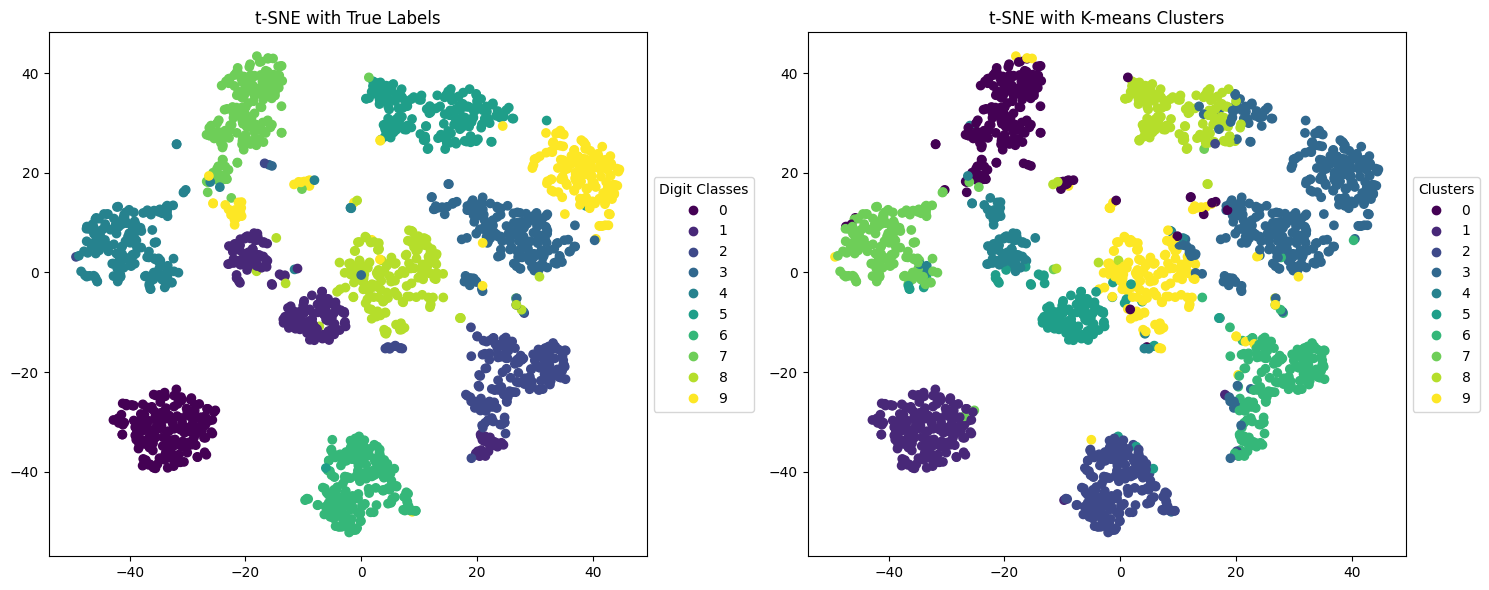

In [14]:
# Load libraries
from sklearn.cluster import KMeans

# Apply K-means clustering
kmeans = KMeans(n_clusters=10, random_state=2024)
cluster_labels = kmeans.fit_predict(digits.data)

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot using true labels
scatter1 = ax1.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=digits.target, cmap='viridis')
ax1.set_title('t-SNE with True Labels')
legend1 = ax1.legend(*scatter1.legend_elements(),
                    title="Digit Classes",
                    loc="center left",
                    bbox_to_anchor=(1, 0.5))

# Plot using cluster labels
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=cluster_labels, cmap='viridis')
ax2.set_title('t-SNE with K-means Clusters')
legend2 = ax2.legend(*scatter2.legend_elements(),
                    title="Clusters",
                    loc="center left",
                    bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

**Interpretasi:** klaster K-means (dihitung pada 64 dimensi asli) sebagian besar selaras dengan kelompok pada ruang t-SNE dan label asli, meski nomor klaster tidak sama dengan nomor digit. Beberapa titik bisa tercampur karena K-means tidak sempurna memisahkan digit yang mirip.

---
## 7. Ringkasan Bab

Bab ini membahas tiga teknik reduksi dimensi: **PCA** (linear, tak terawasi, memaksimalkan variansi), **LDA** (linear, terawasi, memaksimalkan separasi kelas), dan **t-SNE** (non-linear, untuk visualisasi). Pemilihan teknik bergantung pada tujuan, ketersediaan label, dan kebutuhan interpretabilitas.

### Rangkuman Konsep dan Fungsi
| Subbab | Konsep utama | Kelas/Fungsi scikit-learn |
|---|---|---|
| Pengantar | Curse of dimensionality, feature extraction | — |
| PCA | Variansi maksimum, komponen ortogonal | `PCA`, `explained_variance_ratio_`, `n_components=0.95` |
| LDA | Separasi kelas, maks. $k-1$ komponen | `LinearDiscriminantAnalysis` |
| t-SNE | Struktur lokal, non-linear, perplexity | `TSNE` |
| Pemilihan teknik | Label, linearitas, tujuan | Perbandingan PCA/LDA/t-SNE |
| Latihan | PCA + regresi logistik, t-SNE + K-means | `LogisticRegression`, `KMeans`, `accuracy_score` |

**Pesan utama:** selalu **scale** data terlebih dahulu, pilih teknik sesuai tujuan, dan uji dampaknya pada performa model alih-alih mengasumsikannya.